# 07 - Final test: frozen strategy on the untouched period (2024-01 onwards)

Run **once** with the frozen selection in `reports/selection.json`. The model is refitted every 6 months on all earlier data; no parameter changes.

**Event timing:** decision at *t* (candles closed by *t*), execution at the open of *t*+1 min, exit at the open of *t*+61 min.

**Costs per side:** 5 bp fee (sourced) + 1 bp half-spread (assumed) + 1 bp slippage (assumed), charged on every change in position.

Gross and net results are shown side by side and compared with buy-and-hold and a momentum baseline.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))
import pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
import run_pipeline as rp
from src import config
T, F = config.TABLES_DIR, config.FIGURES_DIR
SYMBOL = config.SYMBOL
# False (default): display the outputs saved by scripts/run_pipeline.py.
# True re-computes the stage. Do NOT re-run 'validation' or 'test' casually:
# validation resets the experiment log and every test run adds a TEST row.
RUN_STAGE = False
def show(name, **kw):
    display(Markdown(f"**{name}**")); display(pd.read_csv(T / name, **kw))
def fig(name):
    display(Image(filename=str(F / name)))
def results(section):
    return json.loads((config.REPORTS_DIR / "results.json").read_text()).get(section, {})

In [2]:
if RUN_STAGE:
    rp.stage_test(SYMBOL)

In [3]:
show('test_benchmarks.csv')

**test_benchmarks.csv**

,strategy,periods,years,cumulative_return,annualized_return,annualized_vol,sharpe,sortino,max_drawdown,calmar,gross_sum,cost_sum,funding_sum,net_sum,gross_sharpe,exposure,n_position_changes,turnover_per_year,trades_per_year,round_trips_per_year,win_rate,avg_win,avg_loss,profit_factor,sharpe_ci_low,sharpe_ci_high,psr_vs_0
0,model strategy,24095,2.748688,-0.921683,-0.604111,0.156526,-5.840966,-7.058992,-0.923006,-0.654504,0.069985,2.5676,-0.015403,-2.513018,0.164526,0.091222,3668,1334.454783,1334.454783,667.227392,0.492721,0.003165,-0.004177,0.736062,-6.943012,-4.765683,6.945767e-27
1,buy and hold,24095,2.748688,0.976319,0.281256,0.470203,0.762195,1.078982,-0.536547,0.524195,0.986493,0.0014,0.000000,0.985093,0.763277,1.000000,2,0.727620,0.727620,0.363810,0.504877,0.003247,-0.003229,1.025579,NaN,NaN,NaN
2,momentum 1h sign,24095,2.748688,-1.000000,-0.999068,0.473951,-14.479794,-18.981452,-1.000000,-0.999068,-1.219238,17.6442,0.000000,-18.863438,-0.943465,0.999958,12605,9170.192820,4585.824030,4585.096410,0.383207,0.003392,-0.003377,0.624088,NaN,NaN,NaN


In [4]:
show('test_per_block.csv')

**test_per_block.csv**

,block,auc,net_sharpe,net_cum_return,buy_hold_cum_return,exposure
0,2024H1,0.557668,-5.756953,-0.350258,0.483080,0.086538
1,2024H2,0.566992,-3.379569,-0.272795,0.491190,0.104620
2,2025H1,0.536223,-6.646011,-0.459523,0.144379,0.117403
3,2025H2,0.535083,-8.267457,-0.442747,-0.181826,0.085824
4,2026H1,0.534339,-6.227095,-0.380186,-0.330207,0.080801
5,2026H2,0.532158,-6.191744,-0.112097,0.424964,0.053466


In [5]:
show('test_calibration.csv')

**test_calibration.csv**

,decile,n,mean_p,observed_up,ci_low,ci_high,mean_fwd_ret_bp
0,1,2410,0.401434,0.438174,0.418479,0.458067,0.063082
1,2,2409,0.434932,0.458697,0.438880,0.478645,-1.339058
2,3,2410,0.460173,0.480083,0.460184,0.500046,-1.330305
3,4,2409,0.481257,0.483603,0.463689,0.503569,-0.668485
4,5,2410,0.501198,0.498755,0.478811,0.518704,0.397425
5,6,2409,0.521065,0.509755,0.489792,0.529687,1.066422
6,7,2409,0.540701,0.520963,0.500996,0.540863,1.188776
7,8,2410,0.558994,0.551037,0.531113,0.570799,1.889637
8,9,2409,0.576888,0.543794,0.523850,0.563599,0.759013
9,10,2410,0.599978,0.563900,0.544015,0.583582,0.806418


In [6]:
show('test_confusion.csv')

**test_confusion.csv**

,Unnamed: 0,pred_down,pred_up
0,actual_down,5698,6232
1,actual_up,4982,7183


In [7]:
show('test_importance.csv')

**test_importance.csv**

,feature,gain,gain_share
0,ret_4h,4374.030621,0.196971
1,ret_60m,3519.107587,0.158472
2,clv_60m,2672.411623,0.120344
3,ret_15m,2324.841667,0.104692
4,ret_30m,1632.078000,0.073495
5,ma_dist_24h,1394.876486,0.062814
6,ret_5m,974.032980,0.043862
7,ret_24h,944.593617,0.042537
8,rel_volume_60m,877.481404,0.039515
9,vol_ratio,697.987490,0.031432


In [8]:
show('test_drift.csv')

**test_drift.csv**

,block,ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,ret_24h,ma_dist_24h,log_rv_60m,log_rv_24h,vol_ratio,range_rel_60m,rel_volume_60m,volume_chg_60m,taker_imb_60m,clv_60m,score_psi_vs_first_block
0,2024H1,0.087511,0.058197,0.038205,0.028158,0.032535,0.039397,0.036169,0.038026,0.231100,0.394562,0.025343,0.011404,0.109403,0.007704,0.037017,0.010593,0.000000
1,2024H2,0.084969,0.055100,0.031026,0.032155,0.029084,0.030163,0.059571,0.061736,0.271743,0.610038,0.030934,0.014403,0.135851,0.035400,0.124543,0.048563,0.005514
2,2025H1,0.158119,0.119102,0.072672,0.062838,0.059781,0.061427,0.110572,0.086965,0.379183,0.724812,0.027375,0.009296,0.149972,0.015072,0.288722,0.042278,0.009557
3,2025H2,0.317426,0.262094,0.194527,0.173994,0.156156,0.154530,0.312975,0.208583,0.838092,1.385026,0.022459,0.009045,0.101695,0.029446,0.366626,0.041783,0.020019
4,2026H1,0.159495,0.193875,0.109536,0.080135,0.065949,0.074532,0.138744,0.127712,0.368978,0.673665,0.017988,0.011763,0.076340,0.051629,0.296621,0.008793,0.040551
5,2026H2,0.452273,0.411884,0.352141,0.297965,0.283596,0.281449,0.597209,0.395792,1.178634,3.511288,0.032561,0.012039,0.042929,0.031857,0.320499,0.021989,0.107680


In [9]:
show('test_backtest_sample_rows.csv')

**test_backtest_sample_rows.csv**

,decision_time,entry_time,exit_time,entry_price,exit_price,fwd_ret,position,prev_position,turnover,cost,gross_ret,funding_ret,net_ret
0,2024-01-01 00:00:00+00:00,2024-01-01 00:01:00+00:00,2024-01-01 01:01:00+00:00,42298.62,42455.47,0.003708,0.0,0.0,0.0,0.0000,0.000000,-0.0,0.000000
1,2024-01-01 01:00:00+00:00,2024-01-01 01:01:00+00:00,2024-01-01 02:01:00+00:00,42455.47,42603.95,0.003497,0.0,0.0,0.0,0.0000,0.000000,-0.0,0.000000
2,2024-01-01 02:00:00+00:00,2024-01-01 02:01:00+00:00,2024-01-01 03:01:00+00:00,42603.95,42575.09,-0.000677,0.0,0.0,0.0,0.0000,-0.000000,-0.0,-0.000000
3,2024-01-01 03:00:00+00:00,2024-01-01 03:01:00+00:00,2024-01-01 04:01:00+00:00,42575.09,42336.13,-0.005613,0.0,0.0,0.0,0.0000,-0.000000,-0.0,-0.000000
4,2024-01-01 04:00:00+00:00,2024-01-01 04:01:00+00:00,2024-01-01 05:01:00+00:00,42336.13,42400.44,0.001519,0.0,0.0,0.0,0.0000,0.000000,-0.0,0.000000
5,2024-01-01 05:00:00+00:00,2024-01-01 05:01:00+00:00,2024-01-01 06:01:00+00:00,42400.44,42220.13,-0.004253,0.0,0.0,0.0,0.0000,-0.000000,-0.0,-0.000000
6,2024-01-01 06:00:00+00:00,2024-01-01 06:01:00+00:00,2024-01-01 07:01:00+00:00,42220.13,42423.61,0.004820,1.0,0.0,1.0,0.0007,0.004820,-0.0,0.004120
7,2024-01-01 07:00:00+00:00,2024-01-01 07:01:00+00:00,2024-01-01 08:01:00+00:00,42423.61,42494.98,0.001682,0.0,1.0,1.0,0.0007,0.000000,-0.0,-0.000700
8,2024-01-01 08:00:00+00:00,2024-01-01 08:01:00+00:00,2024-01-01 09:01:00+00:00,42494.98,42556.04,0.001437,0.0,0.0,0.0,0.0000,0.000000,-0.0,0.000000
9,2024-01-01 09:00:00+00:00,2024-01-01 09:01:00+00:00,2024-01-01 10:01:00+00:00,42556.04,42653.56,0.002292,0.0,0.0,0.0,0.0000,0.000000,-0.0,0.000000


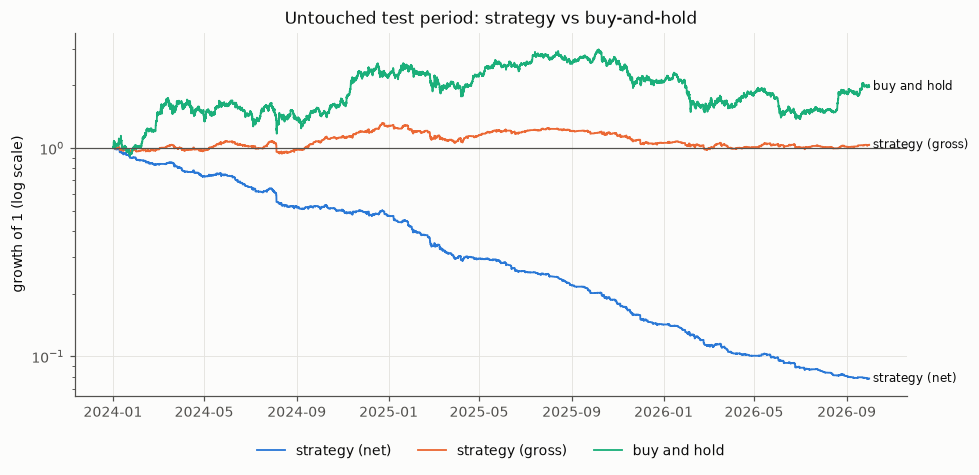

In [10]:
fig('test_equity.png')

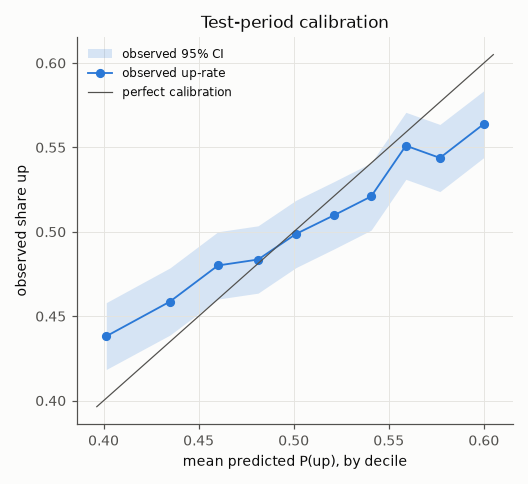

In [11]:
fig('test_calibration.png')

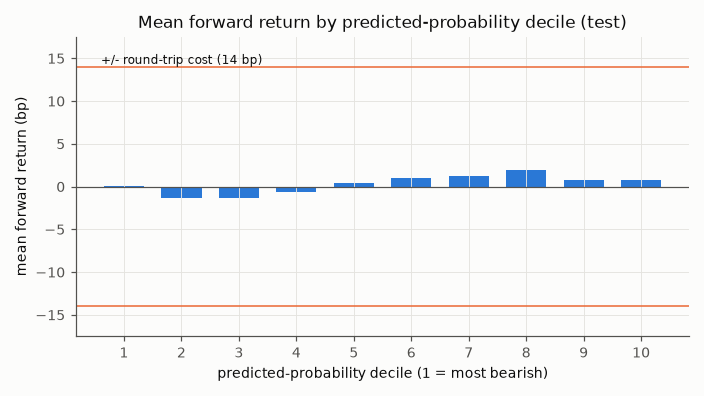

In [12]:
fig('test_decile_returns.png')

**Interpretation:** see the matching section of `reports/final_report.md`, written from these outputs.